In [1]:
#数据获取
import baostock as bs
import pandas as pd
import os
import datetime

class StockDataLoader:
    def __init__(self, stock_code, start_date, end_date=None, data_dir='./data'):
        self.stock_code = stock_code
        self.start_date = start_date
        self.end_date = end_date if end_date else datetime.datetime.now().strftime('%Y-%m-%d')
        self.data_dir = data_dir
        
        if not os.path.exists(self.data_dir):
            os.makedirs(self.data_dir)
            
        self.file_path = os.path.join(self.data_dir, f"{stock_code}_{start_date}_{self.end_date}.csv")

    def _clean_raw_data(self, df):
        """
        内部清洗逻辑：确保无论如何都返回一个 DataFrame
        """
        # 1. 拷贝一份，防止修改原始引用带来的隐患
        df = df.copy()
        
        # 2. 类型转换
        numeric_cols = ['open', 'high', 'low', 'close', 'volume', 'amount']
        # 确保这些列存在，防止 KeyError
        valid_cols = [c for c in numeric_cols if c in df.columns]
        df[valid_cols] = df[valid_cols].apply(pd.to_numeric, errors='coerce')

        # 3. 时间标准化
        if 'time' in df.columns:
            df['time'] = pd.to_datetime(df['time'], format='%Y%m%d%H%M%S%f')
            df = df.set_index('time').sort_index()
        
        # 4. 删除多余列
        if 'date' in df.columns:
            df = df.drop(columns=['date'])
            
        # 【关键】必须在所有缩进块之外返回 df
        return df

    def download_data(self, frequency="5"):
        # 1. 检查本地缓存
        if os.path.exists(self.file_path):
            print(f"检测到本地缓存: {self.file_path}")
            try:
                df = pd.read_csv(self.file_path, index_col='time', parse_dates=['time'])
                print(f"本地数据加载成功，行数: {len(df)}")
                return df
            except Exception as e:
                print(f"本地文件读取失败 ({e})，准备重新下载...")

        # 2. Baostock 下载
        print(f"正在连接 Baostock 下载 {self.stock_code}...")
        bs.login()
        
        rs = bs.query_history_k_data_plus(
            self.stock_code,
            "date,time,open,high,low,close,volume,amount",
            start_date=self.start_date, 
            end_date=self.end_date,
            frequency=frequency, 
            adjustflag="2"
        )

        data_list = []
        while rs.next():
            data_list.append(rs.get_row_data())
        
        bs.logout()

        if not data_list:
            raise ValueError(f"Baostock 未返回任何数据! 请检查:\n1. 股票代码是否正确 (如 'sh.600519')\n2. 日期范围 ({self.start_date} 是否在上市后)\n3. 是否是交易日")

        # 3. 转换为 DataFrame
        df = pd.DataFrame(data_list, columns=rs.fields)
        
        # 4. 执行清洗
        df = self._clean_raw_data(df)
        
        # 【防御性检查】确保清洗后 df 依然存在
        if df is None:
            raise ValueError("严重错误：_clean_raw_data 返回了 None，请检查代码缩进！")

        # 5. 保存
        try:
            df.to_csv(self.file_path)
            print(f"数据已下载并清洗，保存至: {self.file_path}")
        except Exception as e:
            print(f"警告: 数据保存失败 ({e})，但将返回内存中的 DataFrame")

        return df

    def resample_data(self, df, rule='60min'):
        """
        重采样：从 5分钟 (含噪音) -> 小时/日线 (趋势)
        """
        # 确保 df 索引是时间类型
        if not isinstance(df.index, pd.DatetimeIndex):
            df.index = pd.to_datetime(df.index)
            
        agg_dict = {
            'open': 'first',
            'high': 'max',
            'low': 'min',
            'close': 'last',
            'volume': 'sum',
            'amount': 'sum'
        }
        
        # 仅对存在的列进行聚合
        valid_agg = {k: v for k, v in agg_dict.items() if k in df.columns}
        
        df_res = df.resample(rule, label='right', closed='right').agg(valid_agg)
        df_res = df_res.dropna()
        
        print(f"重采样完成: {len(df)} (原始) -> {len(df_res)} ({rule})")
        return df_res



In [2]:
#只有从2019开始的分钟线数据
Data=StockDataLoader("sh.600519", "2019-01-01").download_data()
df_raw = Data
df_raw

检测到本地缓存: ./data\sh.600519_2019-01-01_2026-01-26.csv
本地数据加载成功，行数: 82272


,open,high,low,close,volume,amount
time,,,,,,
2019-01-02 09:35:00,520.781405,522.506016,516.529640,519.517828,1552766,945850400.0
2019-01-02 09:40:00,519.577592,520.798480,517.511473,517.554162,395656,240900640.0
2019-01-02 09:45:00,517.383408,518.237176,515.564882,515.803937,332316,201314560.0
2019-01-02 09:50:00,516.179595,516.529640,514.156165,516.145444,201370,121501600.0
2019-01-02 09:55:00,516.145444,516.529640,511.407032,511.483871,361837,217579824.0
...,...,...,...,...,...,...
2026-01-23 14:40:00,1335.360000,1336.770000,1332.710000,1334.000000,581350,775614285.0
2026-01-23 14:45:00,1334.380000,1337.650000,1334.380000,1337.170000,91407,122180265.0
2026-01-23 14:50:00,1337.160000,1337.280000,1334.380000,1335.200000,194476,259865095.0


In [3]:
#特征工程

import pandas as pd
import numpy as np

def perform_feature_engineering(df_raw):
    """
    输入: df_raw (5分钟原始数据, 含噪音 g(t))
    输出: X (特征矩阵), y (标签), df_final (用于分析的完整数据)
    """
    
    # ==========================================
    # 1. 物理降噪：重采样为 60分钟线
    # ==========================================
    # A股每天4小时交易，60min线每天4根。
    # 这相当于从物理上滤除了频率高于 1/4天 的 g(t) 噪音
    agg_dict = {
        'open': 'first', 'high': 'max', 'low': 'min', 'close': 'last',
        'volume': 'sum', 'amount': 'sum'
    }
    # 确保索引是datetime
    if not isinstance(df_raw.index, pd.DatetimeIndex):
        df_raw.index = pd.to_datetime(df_raw.index)
        
    df = df_raw.resample('60min', closed='right', label='right').agg(agg_dict).dropna()
    print(f"数据重采样完成: {len(df_raw)} (5min) -> {len(df)} (60min)")

    # ==========================================
    # 2. 构造描述 f(t) 的特征
    # ==========================================
    
    # --- A. 均线系统 (拟合 f(t)) ---
    # MA5 (短期，约1天多), MA20 (中期，约1周), MA60 (长期，约3周)
    # 注意：这里的周期是 60min K线的根数
    df['ma_5'] = df['close'].rolling(window=5).mean()
    df['ma_20'] = df['close'].rolling(window=20).mean()   # 近似 f(t)
    df['ma_60'] = df['close'].rolling(window=60).mean()   # 更平滑的 f(t)
    
    # --- B. 趋势斜率 (Derivative of f(t)) ---
    # 计算均线的变化率，而不是价格的变化率
    # 逻辑：如果 ma_60 的斜率 > 0，说明长期趋势向上
    def calculate_slope(series, period=3):
        return (series - series.shift(period)) / series.shift(period)

    df['slope_ma5'] = calculate_slope(df['ma_5'])
    df['slope_ma20'] = calculate_slope(df['ma_20']) # 核心特征
    df['slope_ma60'] = calculate_slope(df['ma_60']) # 核心特征
    
    # --- C. 均线纠缠/发散 (Convergence/Divergence) ---
    # 短期均线相对于长期均线的位置
    df['dist_ma5_ma20'] = (df['ma_5'] - df['ma_20']) / df['ma_20']
    df['dist_ma20_ma60'] = (df['ma_20'] - df['ma_60']) / df['ma_60']
    
    # --- D. 相对波动率 (用于动态阈值) ---
    # ATR 计算
    high_low = df['high'] - df['low']
    high_close = np.abs(df['high'] - df['close'].shift())
    low_close = np.abs(df['low'] - df['close'].shift())
    ranges = pd.concat([high_low, high_close, low_close], axis=1)
    true_range = np.max(ranges, axis=1)
    df['atr'] = true_range.rolling(window=20).mean()
    # 归一化波动率 (ATR%)
    df['atr_pct'] = df['atr'] / df['close']

    # --- E. 动量特征 (RSI on MA) ---
    # 对平滑后的 ma_20 计算 RSI，而不是对 close 计算
    # 这能避免因 g(t) 导致的 RSI 频繁钝化
    def calculate_rsi(data, window=14):
        delta = data.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
        rs = gain / loss
        return 100 - (100 / (1 + rs))
    
    df['rsi_ma20'] = calculate_rsi(df['ma_20'], window=14)

    # --- F. 滞后特征 (Lagging Features) ---
    # 这里的关键是：让模型看到“过去 N 小时” f(t) 是如何变化的
    # 我们不再输入原始价格，而是输入“斜率的历史”
    feature_cols_base = ['slope_ma20', 'slope_ma60', 'dist_ma5_ma20', 'dist_ma20_ma60', 'atr_pct', 'rsi_ma20']
    
    lags = [1, 2, 4, 8] # 回看过去 1, 2, 4, 8 个小时的情况
    for col in feature_cols_base:
        for lag in lags:
            df[f'{col}_lag{lag}'] = df[col].shift(lag)

    # ==========================================
    # 3. 标签生成 (Robust Labeling)
    # ==========================================
    # 目的：确定当前时刻 f(t) 的涨跌趋势
    # 方法：比较 "未来 N 周期均价" 与 "当前 N 周期均价"
    # 牺牲时间：预测未来 8 个周期 (约2个交易日) 后的趋势
    
    prediction_horizon = 8  # 预测未来 8 小时
    smooth_window = 4       # 使用 4 小时均价来代表 f(t)，消除单点 g(t) 干扰
    
    # 当前平滑价格
    curr_smooth = df['close'].rolling(window=smooth_window).mean()
    # 未来平滑价格 (shift负数表示读取未来数据)
    future_smooth = df['close'].rolling(window=smooth_window).mean().shift(-prediction_horizon)
    
    # 计算趋势收益率
    df['trend_return'] = (future_smooth - curr_smooth) / curr_smooth
    
    # 动态阈值：要求趋势收益必须大于 0.8 倍的 ATR (波动幅度)
    # 这样只有当 f(t) 的变化显著大于 g(t) 的噪音时，才标记为趋势
    threshold = df['atr_pct'] * 0.8
    
    # 定义标签
    # 2: 明显上涨 (Trend Up)
    # 1: 明显下跌 (Trend Down)
    # 0: 震荡/不确定 (Noise/Sideways)
    
    conditions = [
        (df['trend_return'] > threshold),   # 上涨
        (df['trend_return'] < -threshold)   # 下跌
    ]
    choices = [2, 1]
    df['label'] = np.select(conditions, choices, default=0)

    # ==========================================
    # 4. 清洗与输出
    # ==========================================
    # 移除包含 NaN 的行 (因为计算 MA 和 shift 产生的)
    df_final = df.dropna()
    
    # 提取特征列
    # 排除所有以 'close', 'open', 'high', 'low', 'volume' 开头的原始列
    # 只保留我们计算出的衍生特征
    exclude_keywords = ['open', 'high', 'low', 'close', 'volume', 'amount', 'ma_', 'label', 'trend_return', 'atr']
    feature_cols = [c for c in df_final.columns if not any(k == c for k in exclude_keywords)]
    # 注意：我们保留 slope, dist, lag 等特征，剔除原始绝对价格
    
    print("\n特征工程完成。")
    print(f"最终样本数: {len(df_final)}")
    print(f"标签分布:\n{df_final['label'].value_counts(normalize=True)}")
    print(f"特征列表 (前10个): {feature_cols[:10]} ... 总共 {len(feature_cols)} 个特征")
    
    X = df_final[feature_cols]
    y = df_final['label']
    
    return X, y, df_final

# 假设 df_raw 已经存在 (来自上一步)
# 执行特征工程
if 'df_raw' in locals():
    X, y, df_clean = perform_feature_engineering(df_raw)
else:
    print("请先运行数据获取代码以生成 df_raw")

X

数据重采样完成: 82272 (5min) -> 8570 (60min)

特征工程完成。
最终样本数: 8492
标签分布:
label
0    0.341027
2    0.333490
1    0.325483
Name: proportion, dtype: float64
特征列表 (前10个): ['ma_5', 'ma_20', 'ma_60', 'slope_ma5', 'slope_ma20', 'slope_ma60', 'dist_ma5_ma20', 'dist_ma20_ma60', 'atr_pct', 'rsi_ma20'] ... 总共 34 个特征


,ma_5,ma_20,ma_60,slope_ma5,slope_ma20,slope_ma60,dist_ma5_ma20,dist_ma20_ma60,atr_pct,rsi_ma20,...,dist_ma20_ma60_lag4,dist_ma20_ma60_lag8,atr_pct_lag1,atr_pct_lag2,atr_pct_lag4,atr_pct_lag8,rsi_ma20_lag1,rsi_ma20_lag2,rsi_ma20_lag4,rsi_ma20_lag8
time,,,,,,,,,,,,,,,,,,,,,
2019-01-22 10:00:00,584.282961,574.836445,545.003372,-0.003059,0.005898,0.007164,0.016433,0.054739,0.012725,100.0,...,0.055630,0.047792,0.012328,0.012800,0.013205,0.011754,100.0,100.0,100.0,100.0
2019-01-22 11:00:00,581.737025,575.513056,546.079973,-0.008596,0.004605,0.006706,0.010815,0.053899,0.012780,100.0,...,0.056067,0.049805,0.012725,0.012328,0.013282,0.012019,100.0,100.0,100.0,100.0
2019-01-22 12:00:00,579.508690,576.059468,547.045870,-0.013361,0.003540,0.005928,0.005988,0.053037,0.012773,100.0,...,0.056103,0.052142,0.012780,0.012725,0.012800,0.012613,100.0,100.0,100.0,100.0
2019-01-22 14:00:00,576.947386,576.304926,547.966943,-0.012555,0.002555,0.005438,0.001115,0.051715,0.012728,100.0,...,0.055542,0.054600,0.012773,0.012780,0.012328,0.012932,100.0,100.0,100.0,100.0
2019-01-22 15:00:00,574.218744,576.727541,548.948776,-0.012924,0.002110,0.005253,-0.004350,0.050604,0.012596,100.0,...,0.054739,0.055630,0.012728,0.012773,0.012725,0.013205,100.0,100.0,100.0,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-21 12:00:00,1368.584000,1378.906000,1404.783833,-0.004883,-0.003045,-0.001560,-0.007486,-0.018421,0.004258,0.0,...,-0.016133,-0.011021,0.004238,0.004452,0.004520,0.005140,0.0,0.0,0.0,0.0
2026-01-21 14:00:00,1366.118000,1377.399500,1403.795833,-0.005739,-0.003069,-0.001842,-0.008190,-0.018804,0.004093,0.0,...,-0.016960,-0.012593,0.004258,0.004238,0.004350,0.004798,0.0,0.0,0.0,0.0
2026-01-21 15:00:00,1361.620000,1375.508000,1402.546833,-0.007097,-0.003528,-0.002215,-0.010097,-0.019278,0.004420,0.0,...,-0.017596,-0.013892,0.004093,0.004258,0.004452,0.004909,0.0,0.0,0.0,0.0


>>> LightGBM 启动: 总月份 85, 初始训练 12 个月
进度: 预测 2020-04 完成...
进度: 预测 2020-09 完成...
进度: 预测 2021-02 完成...
进度: 预测 2021-07 完成...
进度: 预测 2021-12 完成...
进度: 预测 2022-05 完成...
进度: 预测 2022-10 完成...
进度: 预测 2023-03 完成...
进度: 预测 2023-08 完成...
进度: 预测 2024-01 完成...
进度: 预测 2024-06 完成...
进度: 预测 2024-11 完成...
进度: 预测 2025-04 完成...
进度: 预测 2025-09 完成...

LightGBM 最终分类报告
              precision    recall  f1-score   support

           0       0.34      0.26      0.29      2505
           1       0.39      0.33      0.36      2455
           2       0.35      0.49      0.41      2382

    accuracy                           0.36      7342
   macro avg       0.36      0.36      0.36      7342
weighted avg       0.36      0.36      0.35      7342



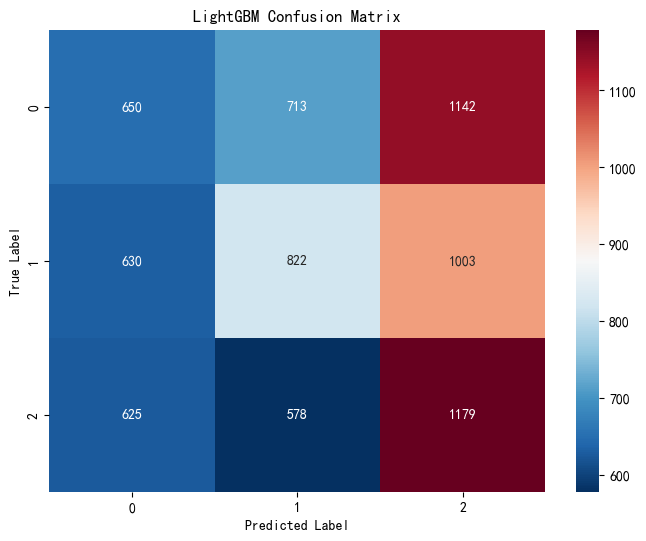

C:\Users\xyp\AppData\Local\Temp\ipykernel_31216\3008032976.py:124: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_acc = eval_res.set_index('date').resample('M')['is_correct'].mean()


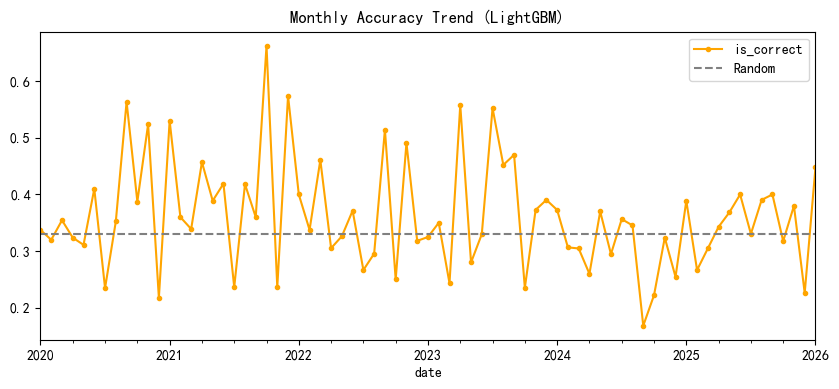

In [ ]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def train_and_eval_lightgbm(data, date_col, feature_cols, target_col, initial_months=12):
    """
    使用 LightGBM 进行滚动窗口预测
    """
    # 排序与时间周期处理
    df = data.sort_values(by=date_col).copy()
    df['period_month'] = df[date_col].dt.to_period('M')
    unique_months = df['period_month'].unique()
    
    if len(unique_months) <= initial_months:
        raise ValueError("数据月份不足")
        
    all_predictions = []
    all_targets = []
    all_dates = []
    
    print(f">>> LightGBM 启动: 总月份 {len(unique_months)}, 初始训练 {initial_months} 个月")
    
    # LightGBM 参数 (针对金融噪声数据的优化配置)
    params = {
        'objective': 'multiclass',
        'num_class': 3,  # 你的类别数: 0, 1, 2
        'metric': 'multi_logloss',
        'boosting_type': 'gbdt',
        'num_leaves': 31,       # 控制复杂度，太高会过拟合
        'learning_rate': 0.05,  # 降低学习率，增加迭代次数
        'feature_fraction': 0.8,# 随机选特征，防止对某一特征过拟合
        'bagging_fraction': 0.8,# 随机选样本
        'bagging_freq': 5,
        'min_data_in_leaf': 50, # 金融数据噪点多，叶子节点样本要大一点
        'random_state': 42,
        'verbosity': -1
    }

    # 滚动训练循环
    for i in range(initial_months, len(unique_months)):
        current_pred_month = unique_months[i]
        
        # 扩展窗口：训练集不断变大
        train_mask = df['period_month'] < current_pred_month
        test_mask = df['period_month'] == current_pred_month
        
        X_train = df.loc[train_mask, feature_cols]
        y_train = df.loc[train_mask, target_col]
        X_test = df.loc[test_mask, feature_cols]
        y_test = df.loc[test_mask, target_col]
        test_dates = df.loc[test_mask, date_col]
        
        if len(X_test) == 0: continue

        # 创建 LGB 数据集
        lgb_train = lgb.Dataset(X_train, y_train)
        
        # 训练模型 (num_boost_round=100)
        clf = lgb.train(params, lgb_train, num_boost_round=100)
        
        # 预测 (输出概率 -> 转为类别)
        y_pred_prob = clf.predict(X_test)
        y_pred = [np.argmax(line) for line in y_pred_prob]
        
        all_predictions.extend(y_pred)
        all_targets.extend(y_test)
        all_dates.extend(test_dates)
        
        if i % 5 == 0:
            print(f"进度: 预测 {current_pred_month} 完成...")

    # 汇总结果
    results_df = pd.DataFrame({
        'date': all_dates,
        'y_true': all_targets,
        'y_pred': all_predictions
    })
    
    return results_df

# ==========================================
# 调用新的 LightGBM 函数
# ==========================================

# 假设 df_clean 和 X 已经准备好 (来自你之前的特征工程步骤)
if 'df_clean' in locals():
    df_train_ready = df_clean.reset_index()
    feature_list = X.columns.tolist()
    
    # 执行训练
    eval_res = train_and_eval_lightgbm(
        data=df_train_ready,
        date_col='time',
        feature_cols=feature_list,
        target_col='label',
        initial_months=12
    )

    # ==========================================
    # 结果分析 (重点看分类报告)
    # ==========================================
    y_true = eval_res['y_true']
    y_pred = eval_res['y_pred']
    
    print("\n" + "="*40)
    print("LightGBM 最终分类报告")
    print("="*40)
    print(classification_report(y_true, y_pred))
    
    # 混淆矩阵可视化
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdBu_r') # 红蓝配色对比更强烈
    plt.title('LightGBM Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    # 准确率趋势
    eval_res['is_correct'] = (eval_res['y_true'] == eval_res['y_pred']).astype(int)
    monthly_acc = eval_res.set_index('date').resample('M')['is_correct'].mean()
    
    plt.figure(figsize=(10, 4))
    monthly_acc.plot(marker='.', color='orange')
    plt.axhline(0.33, color='grey', linestyle='--', label='Random')
    plt.title("Monthly Accuracy Trend (LightGBM)")
    plt.legend()
    plt.show()

else:
    print("请先运行上面的特征工程代码块生成 df_clean")

In [28]:
# ==========================================
# 1. 模拟环境设置 (请替换为你真实的数据变量)
# ==========================================
# 假设你的数据叫 df, 特征是 features, 标签是 'label', 日期是 'trade_date'
# 这里我假设你已经完成了上一步的数据准备
# dataset = df 
# features = [...]
# target = 'label'
# date_column = 'trade_date'

# ==========================================
# 2. 调用滚动训练函数
# ==========================================
print(">>> 开始执行滚动窗口验证 (Expanding Window)...")


# initial_months=12 表示用前12个月的数据训练第一个模型，预测第13个月
# 之后用前13个月训练，预测第14个月，以此类推
eval_results, last_model = train_and_eval_rolling_window(
    data=df,              # 你的数据变量
    date_col='date',      # 你的日期列名
    feature_cols=features,# 你的特征列名list
    target_col='label',   # 你的目标列名
    initial_months=12     # 或者是你希望的初始训练长度
)

# ==========================================
# 3. 计算评估指标
# ==========================================
print("\n" + "="*40)
print(">>> 模型性能综合评估报告")
print("="*40)

y_true = eval_results['y_true']
y_pred = eval_results['y_pred']

# 基础指标
acc = accuracy_score(y_true, y_pred)
try:
    roc_auc = roc_auc_score(y_true, y_pred) # 如果是二分类且有概率输出更好，这里用预测类别近似
except:
    roc_auc = "N/A (Need Probabilities)"

print(f"总体准确率 (Accuracy): {acc:.4f}")
print(f"ROC AUC Score: {roc_auc}")
print("\n详细分类报告:")
print(classification_report(y_true, y_pred))

# ==========================================
# 4. 可视化：混淆矩阵与热力图
# ==========================================
plt.figure(figsize=(10, 6))

# 计算混淆矩阵
cm = confusion_matrix(y_true, y_pred)

# 绘制热力图
# annot=True 显示数值, fmt='d' 显示整数, cmap='Blues' 蓝色系
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

plt.title('Confusion Matrix (Rolling Validation)', fontsize=15)
plt.ylabel('True Label (Real Market Move)', fontsize=12)
plt.xlabel('Predicted Label (Model Signal)', fontsize=12)

# 添加标签解释 (假设 0是跌/平, 1是涨)
plt.xticks([0.5, 1.5], ['Class 0', 'Class 1']) 
plt.yticks([0.5, 1.5], ['Class 0', 'Class 1'], rotation=0)

plt.show()

# ==========================================
# 5. (可选) 随时间变化的准确率可视化
# ==========================================
# 金融模型常常会失效，观察性能随时间的衰减很重要
eval_results['is_correct'] = (eval_results['y_true'] == eval_results['y_pred']).astype(int)
eval_results['month'] = eval_results['date'].dt.to_period('M')
monthly_accuracy = eval_results.groupby('month')['is_correct'].mean()

plt.figure(figsize=(12, 4))
monthly_accuracy.plot(marker='o', linestyle='-', color='green')
plt.title('Monthly Accuracy Trend', fontsize=12)
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.axhline(y=0.5, color='r', linestyle='--', label='Random Guess')
plt.legend()
plt.show()

>>> 开始执行滚动窗口验证 (Expanding Window)...


KeyError: 'date'